In [179]:
##import dependencies
import numpy as np
import matplotlib.pyplot as plt


In [180]:
##define the function f(z) = (e^z - 1) / z
def f(z):
    return (np.exp(z) - 1) / z

##define a vector containing z logarithmically base 10 spaced between 1e-10 and 1, reverse order
z = np.logspace(-15, 0, 16, dtype=np.longdouble)[::-1]

In [181]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

In [182]:
f(z)

array([1.71828183, 1.05170918, 1.00501671, 1.00050017, 1.00005   ,
       1.000005  , 1.0000005 , 1.00000005, 0.99999999, 1.00000008,
       1.00000008, 1.00000008, 1.0000889 , 0.99920072, 0.99920072,
       1.11022302])

In [183]:
##compute the Taylor series expansion of f(z) around z = 0 up to order 8
## f(z) = 1 + z/2 + z^2/6 + z^3/24 + z^4/120 + z^5/720 + z^6/5040 + z^7/40320 + z^8/362880 
##force to maintain high precision by using the decimal module
def taylor_series(z):
    return sum(z**n/factorial(n+1) for n in range(18))


In [184]:
taylor_series(z)

array([1.71828183, 1.05170918, 1.00501671, 1.00050017, 1.00005   ,
       1.000005  , 1.0000005 , 1.00000005, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [185]:
##export f(z) and taylor_series(z) to a csv file
import pandas as pd
df = pd.DataFrame({'z': z, 'f(z)': f(z), 'taylor_series(z)': taylor_series(z)})
df.to_csv('coefficient_approx.csv', index=False)

In [186]:
def alpha(z):
    return (-4-z+np.exp(z)*(4-3*z+z**2))/(z**3)

In [187]:
def taylor_coefficient(n):
    return 4/factorial(n+3) - 3/factorial(n+2) + 1/factorial(n+1)

In [188]:
def taylor_series_alpha(z):
    return sum(taylor_coefficient(n)*z**n for n in range(18))

In [189]:
z

array([1.e+00, 1.e-01, 1.e-02, 1.e-03, 1.e-04, 1.e-05, 1.e-06, 1.e-07,
       1.e-08, 1.e-09, 1.e-10, 1.e-11, 1.e-12, 1.e-13, 1.e-14, 1.e-15])

In [190]:
taylor_series_alpha(z)

array([0.43656366, 0.18410606, 0.16834086, 0.16683341, 0.16668333,
       0.16666833, 0.16666683, 0.16666668, 0.16666667, 0.16666667,
       0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [191]:
def contour_alpha(c):
    
    M = 64  # number of points for complex means
    r = np.exp(1j * np.pi * (np.arange(1, M + 1)-0.5) / M)
    z = c + r
    return np.real(np.mean((-4-z+np.exp(z)*(4-3*z+z**2))/(z**3)))


In [192]:
contour_points = [contour_alpha(c) for c in z]

C:\Users\Eleph\AppData\Local\Temp\ipykernel_36212\432592022.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(z, np.log(alpha(z)), label='alpha(z)', marker='o')
C:\Users\Eleph\AppData\Local\Temp\ipykernel_36212\432592022.py:2: RuntimeWarning: invalid value encountered in log
  plt.plot(z, np.log(alpha(z)), label='alpha(z)', marker='o')


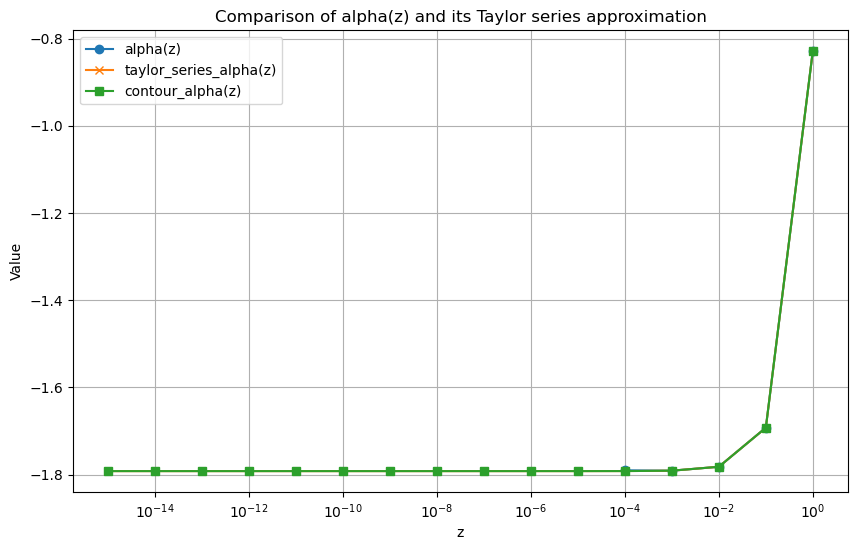

In [193]:
plt.figure(figsize=(10, 6))
plt.plot(z, np.log(alpha(z)), label='alpha(z)', marker='o')
plt.plot(z, np.log(taylor_series_alpha(z)), label='taylor_series_alpha(z)', marker='x')
plt.plot(z, np.log(contour_points), label='contour_alpha(z)', marker='s')
plt.xscale('log')
plt.xlabel('z')
plt.ylabel('Value')
plt.title('Comparison of alpha(z) and its Taylor series approximation')
plt.legend()
plt.grid()

In [194]:
## export alpha(z) and taylor_series_alpha(z) and contour_alpha(z) to a csv file
df_alpha = pd.DataFrame({'z': z, 'alpha(z)': alpha(z), 'contour_alpha(z)': contour_points, 'taylor_series_alpha(z)': taylor_series_alpha(z)})
df_alpha.to_csv('alpha_approx.csv', index=False)

In [195]:
def beta(z):
    return 2+z+np.exp(z)*(-2+z)/(z**3)

def taylor_coefficient_beta(n):
    return -2/factorial(n+3) + 1/factorial(n+2)

def taylor_series_beta(z):
    return sum(taylor_coefficient_beta(n)*z**n for n in range(18))

In [196]:
taylor_series_beta(z)

array([0.28171817, 0.17525566, 0.16750251, 0.16675003, 0.166675  ,
       0.1666675 , 0.16666675, 0.16666668, 0.16666667, 0.16666667,
       0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [197]:
beta(z)

array([ 2.81718172e-01, -2.09772474e+03, -2.00999782e+06, -2.00100000e+09,
       -2.00010000e+12, -2.00001000e+15, -2.00000100e+18, -2.00000010e+21,
       -2.00000001e+24, -2.00000000e+27, -2.00000000e+30, -2.00000000e+33,
       -2.00000000e+36, -2.00000000e+39, -2.00000000e+42, -2.00000000e+45])

C:\Users\Eleph\AppData\Local\Temp\ipykernel_36212\2485537655.py:2: RuntimeWarning: invalid value encountered in log
  plt.plot(z, np.log(beta(z)), label='beta(z)', marker='o')


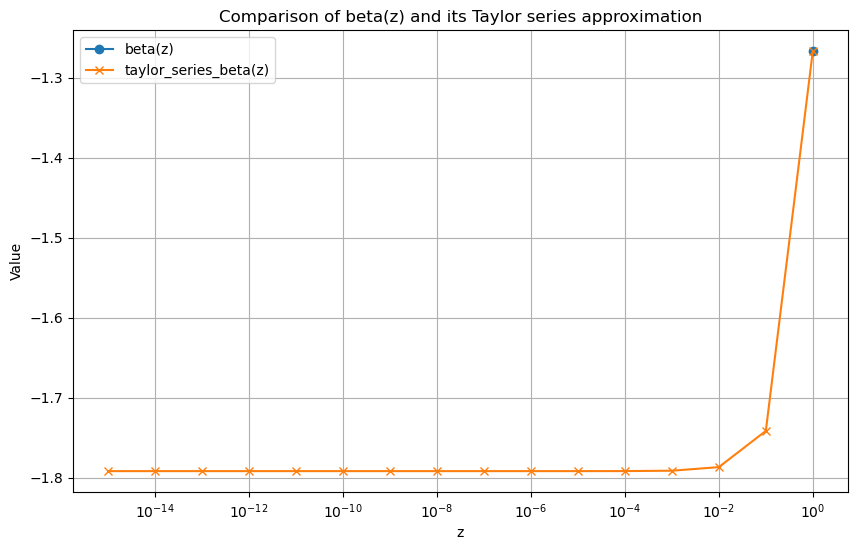

In [198]:
plt.figure(figsize=(10, 6))
plt.plot(z, np.log(beta(z)), label='beta(z)', marker='o')
plt.plot(z, np.log(taylor_series_beta(z)), label='taylor_series_beta(z)', marker='x')
plt.xscale('log')
plt.xlabel('z')
plt.ylabel('Value')
plt.title('Comparison of beta(z) and its Taylor series approximation')
plt.legend()
plt.grid()

plt.show()

In [199]:
def gamma(z):
    return (-4 -3*z -z**2 + np.exp(z)*(4-z))/(z**3)

def taylor_coefficient_gamma(n):
    return 4/factorial(n+3) - 1/factorial(n+2)

def taylor_series_gamma(z):
    return sum(taylor_coefficient_gamma(n)*z**n for n in range(18))


In [200]:
taylor_series_gamma(z)

array([0.15484549, 0.1665805 , 0.16666583, 0.16666666, 0.16666667,
       0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [201]:
##export gamma(z) and taylor_series_gamma(z) to a csv file
df_gamma = pd.DataFrame({'z': z, 'gamma(z)': gamma(z), 'taylor_series_gamma(z)': taylor_series_gamma(z)})
df_gamma.to_csv('gamma_approx.csv', index=False)

C:\Users\Eleph\AppData\Local\Temp\ipykernel_36212\3262655179.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(z, np.log(gamma(z)), label='gamma(z)', marker='o')
C:\Users\Eleph\AppData\Local\Temp\ipykernel_36212\3262655179.py:3: RuntimeWarning: invalid value encountered in log
  plt.plot(z, np.log(gamma(z)), label='gamma(z)', marker='o')


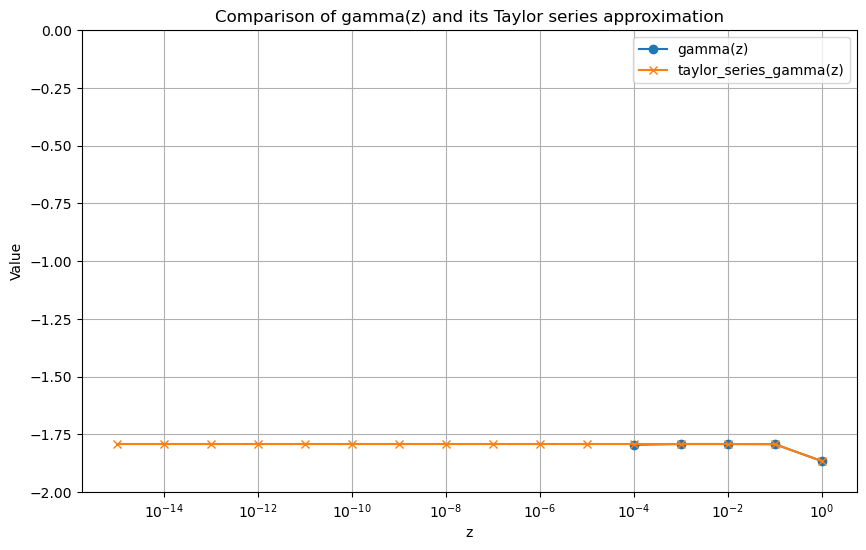

In [202]:
##plot gamma(z) and taylor_series_gamma(z) on the same plot with logarithmic x axis
plt.figure(figsize=(10, 6))
plt.plot(z, np.log(gamma(z)), label='gamma(z)', marker='o')
plt.plot(z, np.log(taylor_series_gamma(z)), label='taylor_series_gamma(z)', marker='x')
plt.xscale('log')
plt.xlabel('z')
plt.ylabel('Value')
plt.title('Comparison of gamma(z) and its Taylor series approximation')
plt.legend()
plt.grid()
plt.ylim(-2, 0)
plt.show()